## Installation of Required Libraries ##

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.9 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.9 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.9 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.9 MB 1.6 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.9 MB 1.6 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.9 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.1/9.9 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.7/9.9 MB 1.7 MB/s eta 0:00:04
   --------------- ------------------------ 3.9/9.9 MB 1.7 MB/s eta 0:00:04
   ------------------ --------------------- 4.5/9.9 MB 1.7 MB/s eta 0:00:04
   ------------------- ---

## Import Required Libraries ##

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Matplotlib is building the font cache; this may take a moment.


## Load Dataset ##
The dataset contains:
- TV Advertising Budget
- Radio Advertising Budget
- Newspaper Advertising Budget
- Sales

In [3]:
df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

## Exploratory Data Analysis (EDA) ##

Let's understand the relationships between advertising budgets and sales.

In [ ]:
df.describe() #Display summary statistics.

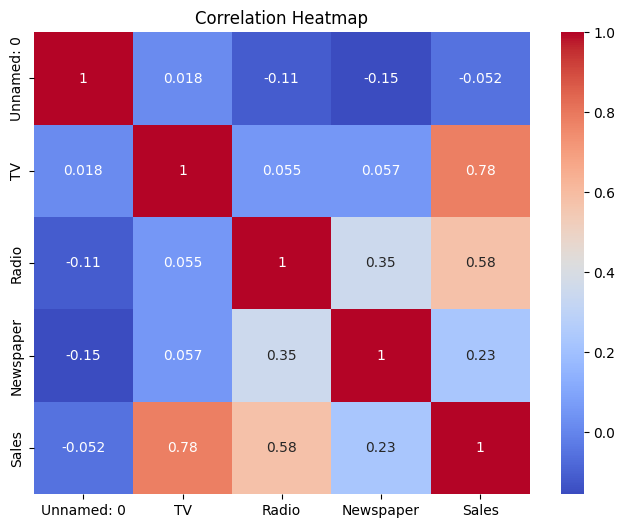

In [6]:
# Correlation Heatmap.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

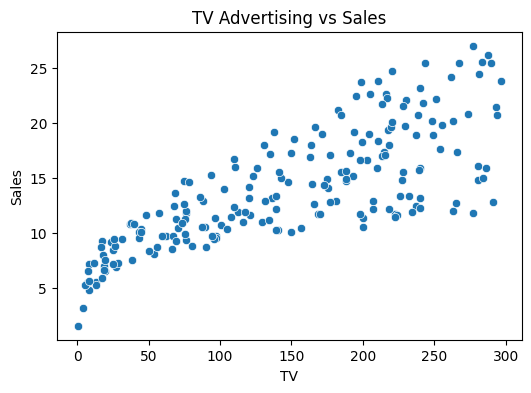

In [7]:
# Visualize TV vs Sales.
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales',data=df)
plt.title("TV Advertising vs Sales")
plt.show()

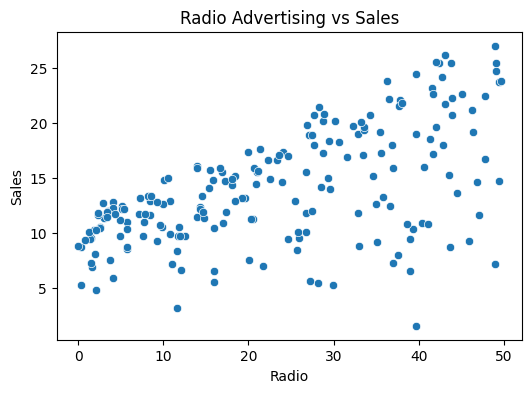

In [8]:
# Visualize Radio vs Sales.

plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio',y='Sales',data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

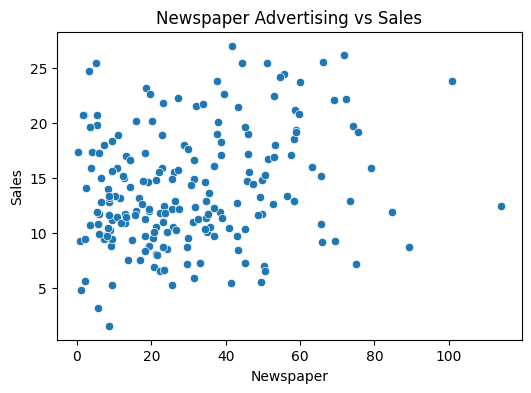

In [9]:
# Visualize Newspaper vs Sales.
plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper',y='Sales',data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

## Feature Selection

Input Features:
- TV
- Radio
- Newspaper

Target Variable:
- Sales

In [10]:
# Split features and target.

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [11]:
#Split dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (160, 3)
Testing Data: (40, 3)


## Model Training

We use Linear Regression to learn the relationship between advertising budget and sales.

In [12]:
# Train the model.
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [13]:
# Model coefficients.

print("Intercept:", model.intercept_)
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)
coefficients

Intercept: 2.979067338122629


,Coefficient
TV,0.044730
Radio,0.189195
Newspaper,0.002761


In [14]:
# Predict sales.

y_pred = model.predict(X_test)
y_pred[:5]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326])

## Model Evaluation

Metrics:
- MAE
- MSE
- R² Score

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
R2 Score: 0.899438024100912


In [16]:
# Actual vs Predicted.
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.head(10)

,Actual,Predicted
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


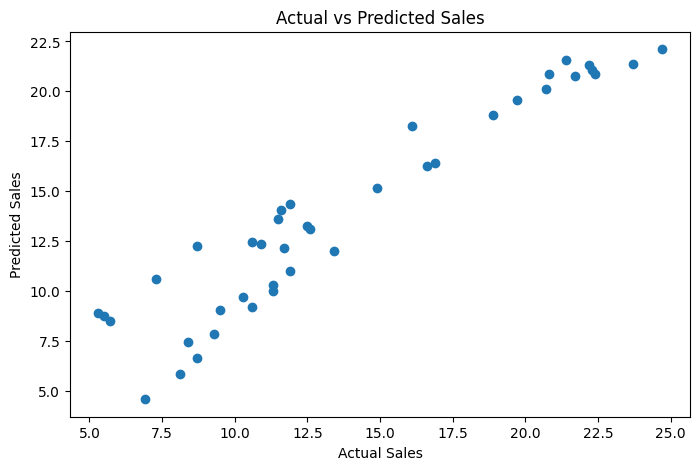

In [17]:
# Visualization of predictions.

plt.figure(figsize=(8,5))
plt.scatter(y_test,
            y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## Future Sales Prediction

Predict sales for a new advertising budget.

In [18]:
new_data = pd.DataFrame({
    'TV':[200],
    'Radio':[40],
    'Newspaper':[30]
})
prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 19.575606431481972


## Feature Importance Analysis

Feature importance helps us understand which advertising platform has the greatest impact on sales.

In [19]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_})
importance = importance.sort_values(by='Importance',ascending=False)
print(importance)

     Feature  Importance
1      Radio    0.189195
0         TV    0.044730
2  Newspaper    0.002761


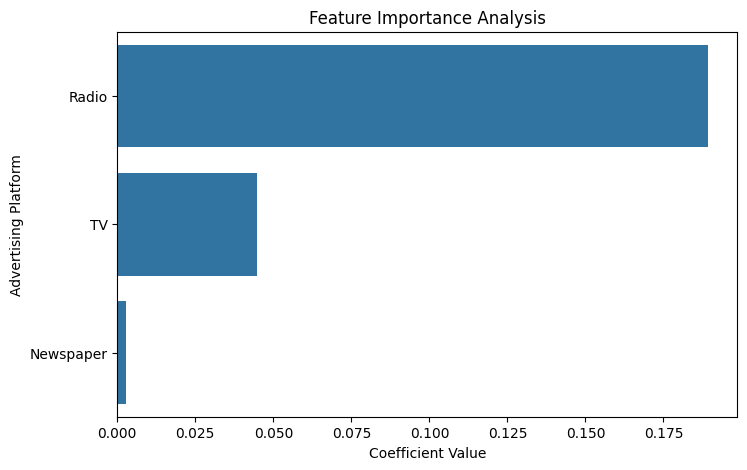

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance Analysis")
plt.xlabel("Coefficient Value")
plt.ylabel("Advertising Platform")
plt.show()

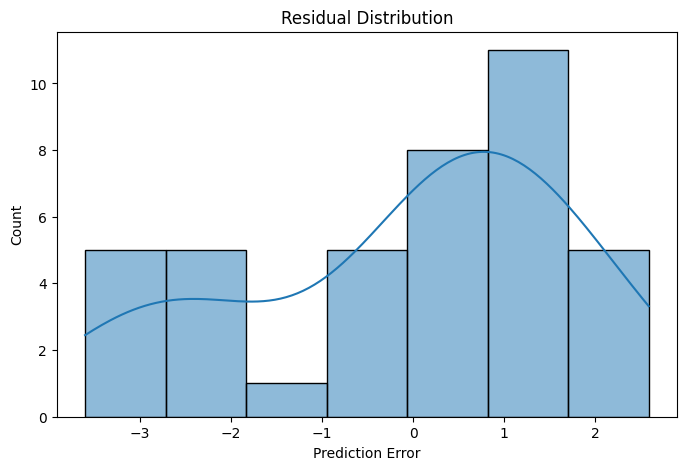

In [21]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

## Model Performance Summary

In [22]:
print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

if r2 > 0.8:
    print("Excellent Model Performance")
elif r2 > 0.6:
    print("Good Model Performance")
else:
    print("Needs Improvement")

MAE : 1.4607567168117603
MSE : 3.1740973539761033
R2 Score : 0.899438024100912
Excellent Model Performance
